# Mixed Type SuStaIn Tutorial

This notebook demonstrates how to run the Mixed Type SuStaIn model using a simulated dataset. Mixed Type SuStaIn is built on top of existing SuStaIn models: Z-score SuStaIn, Mixture SuStaIn (event-based modelling), and Ordinal SuStaIn. It combines these into a single likelihood function, enabling subtype and stage inference from mixed data types. See [de Jonge et al., IEEE ISBI 2026](https://arxiv.org/abs/2602.22018) for more details.

The simulated dataset comprises three biomarker types: continuous biomarkers that reflect piecewise linear progression (modeled as z-score biomarkers), continuous biomarkers that reflect a bimodal distribution (modeled as event/binary biomarkers), and ordinal biomarkers that transition through progressively higher scores (modeled as ordinal biomarkers). Each biomarker type requires different preprocessing. This tutorial walks through the preprocessing steps, shows how to curate the input for `MixedTypeSustain`, fits a model using the same number of subtypes used to generate the data, and demonstrates how to interpret the output.

This tutorial focuses on how to prepare mixed biomarker data for MixedTypeSustain. For more background on SuStaIn settings, cross-validation, and z-score preprocessing, see the other tutorials in this repository: "SuStaIn tutorial using simulated data" and "SuStaInWorkshop".

## Installation and setup

To run this tutorial, install PySuStaIn and its dependencies. If running from the `/notebooks` directory:

In [1]:
# If running from notebooks/, install project requirements:
# %pip install -r ../requirements.txt
# %pip install -e ..
# %pip install statsmodels


# Uncomment and run the lines above if pySuStaIn is not yet installed.
# After installation, restart the kernel before continuing.

## Setup
Define the biomarker groups, preprocessing parameters, and model settings. These settings are matched to the simulation settings used to generate the simulated data.

In [2]:
import os
import numpy as np

# Biomarker definitions
zscore_biomarkers  = ['Zscore-bio-1', 'Zscore-bio-2', 'Zscore-bio-3', 'Zscore-bio-4']
event_biomarkers   = ['event-bio-1', 'event-bio-2']
ordinal_biomarkers = ['ordinal-bio-1', 'ordinal-bio-2']
biomarker_labels   = zscore_biomarkers + ordinal_biomarkers + event_biomarkers

# Preprocessing parameters (matching the simulation settings)
Z_vals_bio   = [1, 2, 3]       # z-score thresholds
Z_max_bio    = 5               # maximum z-score value
score_levels = [1, 2, 3]       # ordinal score range
prob_correct = 0.75            # probability of correct ordinal score assignment

# Model parameters
N_S_max            = 2         # number of subtypes to fit
n_iterations_mcmc  = int(1e4)  # MCMC iterations; use 1e5–1e6 for real data

# Output directory
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)
dataset_name = 'SimulatedMixedType'

## Load and inspect data

The simulated dataset `SimulatedMixedTypeData.csv` contains 500 subjects (150 controls, 350 cases) and 8 biomarkers across three types:
- Z-score biomarkers: Continuous, piecewise linear progression, e.g., brain volumes
- Event/binary biomarkers: Continuous, bimodal distribution, e.g., PET SUVR
- Ordinal biomarkers: Discrete ordinal scores 0–3, e.g., visual rating scores

The data was simulated from 2 ground truth subtypes (0, 1), each with stages 0–20 (0 = control).

In [3]:
import pandas as pd

# Load data
data = pd.read_csv('SimulatedMixedTypeData.csv')

print(f"Dataset shape:         {data.shape}")
print(f"Number of controls:    {(data['diagnosis'] == 0).sum()}")
print(f"Number of cases:       {(data['diagnosis'] == 1).sum()}")
print(f"Ground truth subtypes: {sorted(int(s) for s in data['gt_subtype'].unique())}")
print(f"Ground truth stages:   {int(data['gt_stage'].min())}–{int(data['gt_stage'].max())}\n")

data.head()

Dataset shape:         (500, 14)
Number of controls:    150
Number of cases:       350
Ground truth subtypes: [0, 1]
Ground truth stages:   0–20



,participant_id,gt_subtype,gt_stage,diagnosis,age,head_size,Zscore-bio-1,Zscore-bio-2,Zscore-bio-3,Zscore-bio-4,event-bio-1,event-bio-2,ordinal-bio-1,ordinal-bio-2
0,0,1,6,1,70.9,1484.3,3625.5,1678.7,2600.0,4960.8,-0.192,0.366,1,2
1,1,0,0,0,47.8,1664.4,4475.9,2240.2,3054.9,6127.9,0.516,-0.368,0,0
2,2,0,11,1,51.9,1523.0,4163.1,2051.9,2910.7,5704.0,1.475,-0.046,3,3
3,3,1,13,1,46.3,1568.0,4366.6,2190.7,3016.2,5986.5,-0.276,1.850,1,3
4,4,1,12,1,61.9,1269.3,3529.3,1670.2,2604.3,4843.6,0.275,2.052,1,3


### Inspect z-score biomarkers

Raw distributions of the four continuous volume biomarkers, split by diagnosis. These biomarkers will be modeled as z-score biomarkers after preprocessing.

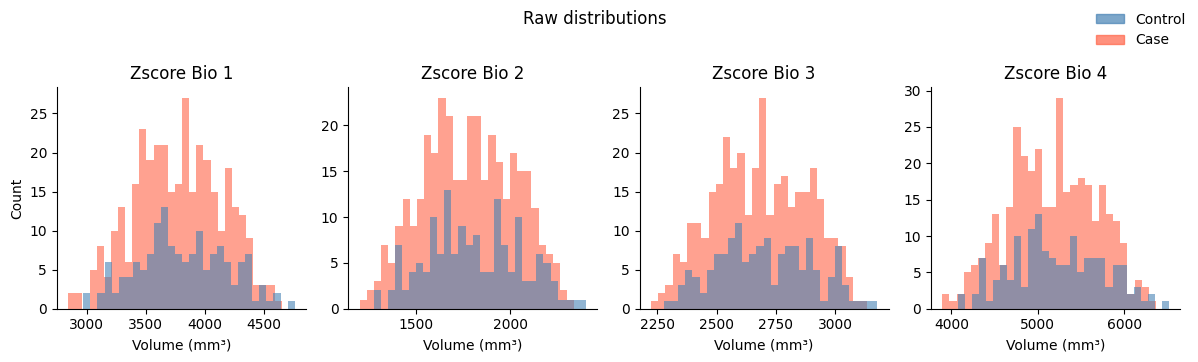

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

controls = data[data['diagnosis'] == 0]
cases    = data[data['diagnosis'] == 1]

n_zscore = len(zscore_biomarkers)
fig, axes = plt.subplots(1, n_zscore, figsize=(3 * n_zscore, 3.5), sharey=False)

for ax, col in zip(axes, zscore_biomarkers):
    ax.hist(cases[col],    bins=30, alpha=0.6, color='tomato')
    ax.hist(controls[col], bins=30, alpha=0.6, color='steelblue')
    ax.set_title(col.replace('-', ' ').title())
    ax.set_xlabel('Volume (mm³)')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Count')

legend_handles = [
    mpatches.Patch(color='steelblue', alpha=0.7, label='Control'),
    mpatches.Patch(color='tomato',    alpha=0.7, label='Case'),
]
fig.legend(handles=legend_handles, loc='upper right', frameon=False)
fig.suptitle('Raw distributions', y=1.02)
plt.tight_layout()
plt.show()

### Inspect event biomarkers

Raw distributions of the two continuous bimodal biomarkers, split by diagnosis. The separation between controls and cases confirms the bimodal structure that allows these biomarkers to be modeled as event biomarkers.

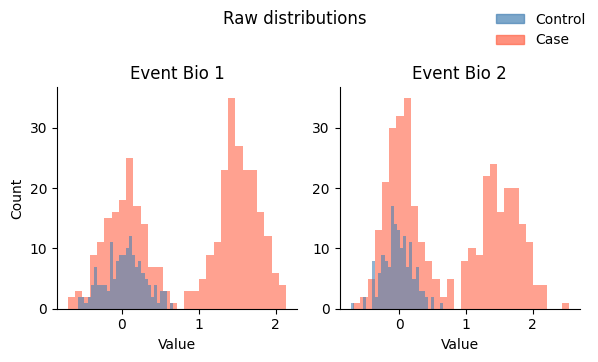

In [5]:
n_event = len(event_biomarkers)
fig, axes = plt.subplots(1, n_event, figsize=(3 * n_event, 3.5), sharey=False)

for ax, col in zip(axes, event_biomarkers):
    ax.hist(cases[col],    bins=30, alpha=0.6, color='tomato')
    ax.hist(controls[col], bins=30, alpha=0.6, color='steelblue')
    ax.set_title(col.replace('-', ' ').title())
    ax.set_xlabel('Value')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Count')

fig.legend(handles=legend_handles, loc='upper right', frameon=False)
fig.suptitle('Raw distributions', y=1.020)
plt.tight_layout()
plt.show()

### Inspect ordinal biomarkers

Score distributions of the two ordinal biomarkers (scores 0–3), split by diagnosis. Controls are predominantly at score 0, while cases show a shift towards higher scores, consistent with the expected ordinal progression.

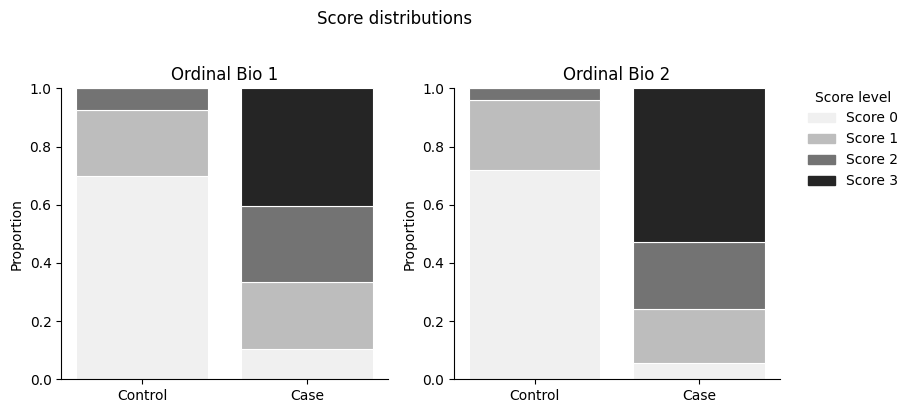

In [6]:
group_labels  = ['Control', 'Case']
groups        = [controls, cases]
group_colors  = ['steelblue', 'tomato']

all_scores = range(max(score_levels) + 1)  # 0, 1, 2, 3

# Ordinal scores: muted sequential palette per score level
score_colors = ['#f0f0f0', '#bdbdbd', '#737373', '#252525']

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, col in zip(axes, ordinal_biomarkers):
    # Compute proportions per score level within each group
    proportions = [
        [(grp[col] == s).sum() / len(grp) for s in all_scores]
        for grp in groups
    ]

    bottoms = [0, 0]
    for i, score in enumerate(all_scores):
        heights = [proportions[g][i] for g in range(len(groups))]
        bars = ax.bar(
            group_labels, heights,
            bottom=bottoms,
            color=score_colors[i],
            edgecolor='white',
            linewidth=0.8,
            label=f'Score {score}'
        )
        bottoms = [bottoms[g] + heights[g] for g in range(len(groups))]

    ax.set_title(col.replace('-', ' ').title())
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)

# Shared legend for score levels
handles = [mpatches.Patch(color=score_colors[i], label=f'Score {i}') for i in all_scores]
fig.legend(handles=handles, title='Score level', bbox_to_anchor=(1.0, 0.85),
           loc='upper left', frameon=False)
fig.suptitle('Score distributions', y=1.02)
plt.tight_layout(rect=(0, 0, 1, 1))  # leave room on the right for legend
plt.show()

## Preprocessing

Each biomarker type requires different preprocessing to transform raw values into the input
format expected by `MixedTypeSustain`. The steps are described per biomarker type below.

### Z-score biomarkers

We z-score the data using the control population as the normative reference. In this example, we assume these biomarkers reflect brain volumes, which is why we first regress out age and head size on the controls to account for two sources of variance unrelated to disease. This correction is then applied to all subjects. Next, the corrected residuals are z-scored using the control mean and standard deviation, so that a z-score of 0 reflects the average control value and ±1 reflects one standard deviation from the control mean.

As shown in the raw distributions above, cases generally have *lower* brain volumes than controls, reflecting atrophy. Because SuStaIn expects biomarker values to *increase* with disease severity, we flip the sign of all z-scores such that higher z-scores indicate more atrophy and greater deviation from the normal reference.

In [7]:
import statsmodels.formula.api as smf

controls_mask = data['diagnosis'] == 0
data_zscore = data.copy()

for col in zscore_biomarkers:
    mod = smf.ols(f"Q('{col}') ~ age + head_size",
                  data=data_zscore[controls_mask]).fit()
    residuals = data_zscore[col] - mod.predict(data_zscore[['age', 'head_size']])

    ctrl_mean = residuals[controls_mask].mean()
    ctrl_std  = residuals[controls_mask].std()
    z = (residuals - ctrl_mean) / ctrl_std

    data_zscore[col] = -z  # flip: higher = more atrophy

# Define Z-score values and Z-max
Z_vals = np.array([Z_vals_bio] * len(zscore_biomarkers), dtype=float)
Z_max  = np.array([Z_max_bio] * len(zscore_biomarkers))

# Define Z-score data to input to MixedTypeSustain
data_zscore_values = data_zscore[zscore_biomarkers].values

print("data_zscore shape:", data_zscore_values.shape)
print("Z_vals:\n", Z_vals)
print("Z_max:", Z_max)

data_zscore shape: (500, 4)
Z_vals:
 [[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]
Z_max: [5 5 5 5]


After preprocessing, controls should be centered around 0 with 1 standard deviation, while cases show a positive shift reflecting disease stage. We can verify this in the following plot.

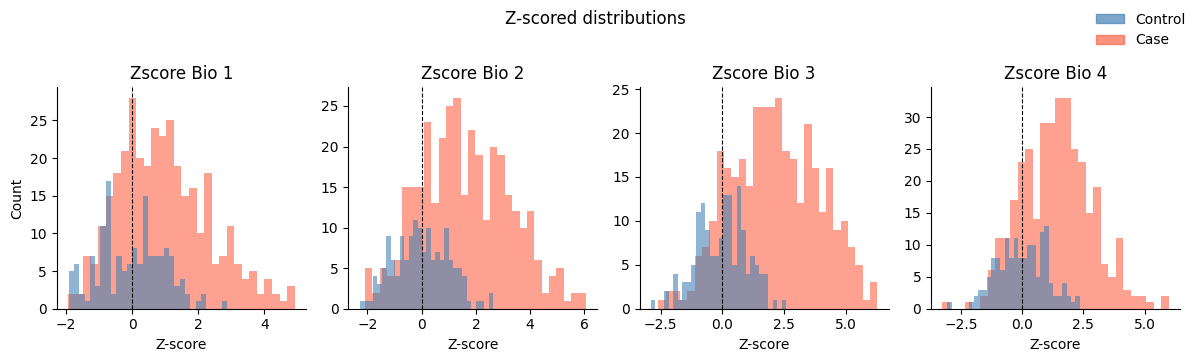

In [8]:
n_zscore = len(zscore_biomarkers)
fig, axes = plt.subplots(1, n_zscore, figsize=(3 * n_zscore, 3.5), sharey=False)

for ax, col in zip(axes, zscore_biomarkers):
    ax.hist(data_zscore.loc[~controls_mask, col], bins=30, alpha=0.6, color='tomato')
    ax.hist(data_zscore.loc[controls_mask, col],  bins=30, alpha=0.6, color='steelblue')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(col.replace('-', ' ').title())
    ax.set_xlabel('Z-score')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Count')
fig.legend(handles=legend_handles, loc='upper right', frameon=False)
fig.suptitle('Z-scored distributions', y=1.02)
plt.tight_layout()
plt.show()

### Event-based biomarkers

For event-based biomarkers, we model each biomarker as a mixture of two Gaussian distributions: a "normal" component (fit to controls) and an "abnormal" component (fit to cases). We use the `ParametricMM` class from the `kde_ebm` package, which fits each component to its respective labeled group. For each subject, we compute the likelihood of belonging to each component: `L_no` (normal) and `L_yes` (abnormal). These likelihoods are normalized so that `L_no + L_yes = 1` per subject per biomarker, and are passed directly to `MixedTypeSustain`.

In [9]:
from kde_ebm.mixture_model import fit_all_gmm_models, get_prob_mat

# kde_ebm expects y as 0 = control, 1 = case
y = data['diagnosis'].values
X_event = data[event_biomarkers].values

# Fit a labeled two-component Gaussian mixture per biomarker
mixture_models = fit_all_gmm_models(X=X_event, y=y)

# Get per-subject likelihoods: prob_mat shape is (N, n_biomarkers, 2)
prob_mat = get_prob_mat(X_event, mixture_models)

# Normalize so that p(normal) + p(abnormal) = 1 per subject per biomarker
L_no  = np.zeros((len(data), len(event_biomarkers)))
L_yes = np.zeros((len(data), len(event_biomarkers)))

for i, col in enumerate(event_biomarkers):
    prob_normal   = prob_mat[:, i, 0]
    prob_abnormal = prob_mat[:, i, 1]
    L_no[:, i]  = prob_normal   / (prob_normal + prob_abnormal)
    L_yes[:, i] = prob_abnormal / (prob_normal + prob_abnormal)

print("L_no shape: ", L_no.shape)
print("L_yes shape:", L_yes.shape)

L_no shape:  (500, 2)
L_yes shape: (500, 2)


We verify the mixture model fits by overlaying the fitted component densities on the raw distributions. The normal component should align with the control peak and the abnormal component with the case peak.

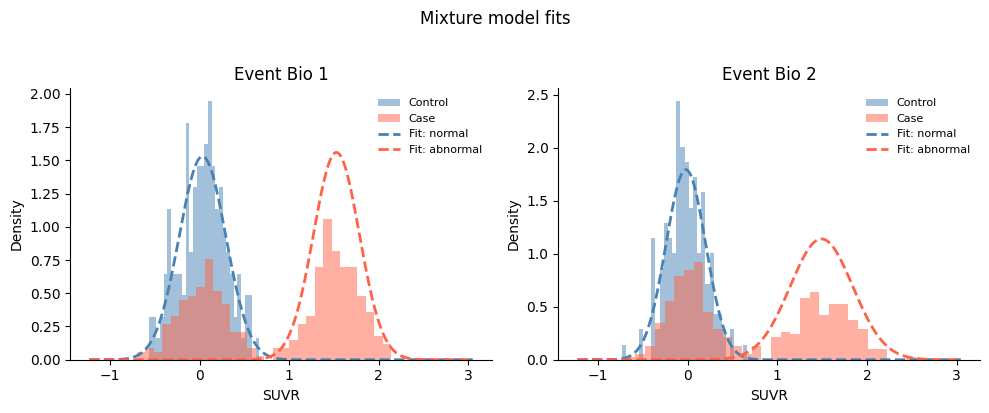

In [17]:
x_range = np.linspace(
    data[event_biomarkers].min().min() - 0.5,
    data[event_biomarkers].max().max() + 0.5,
    300
)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, i in zip(axes, event_biomarkers, range(len(event_biomarkers))):
    ax.hist(data.loc[controls_mask, col],  bins=30, alpha=0.5, color='steelblue',
            density=True, label='Control')
    ax.hist(data.loc[~controls_mask, col], bins=30, alpha=0.5, color='tomato',
            density=True, label='Case')

    mm = mixture_models[i]
    # ParametricMM stores components as mm.cn_comp and mm.ad_comp
    for comp, color, label in [(mm.cn_comp, 'steelblue', 'Fit: normal'),
                                (mm.ad_comp, 'tomato',    'Fit: abnormal')]:
        pdf_vals = np.array([comp.pdf(x) for x in x_range])
        ax.plot(x_range, pdf_vals, color=color, linewidth=2, linestyle='--', label=label)

    ax.set_title(col.replace('-', ' ').title())
    ax.set_xlabel('SUVR')
    ax.set_ylabel('Density')
    ax.legend(frameon=False, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Mixture model fits', y=1.02)
plt.tight_layout()
plt.show()

### Ordinal biomarkers

Ordinal biomarkers take discrete severity scores (0–3), where 0 reflects normality and higher values
indicate increasing abnormality. To use ordinal biomarkers in SuStaIn, each observed score is expressed
as a probability distribution over possible states. Two arrays are required:

- `prob_nl` (N_subjects × N_biomarkers): the probability that a subject's score is consistent with the
  normal state (score = 0).
- `prob_score` (N_subjects × N_biomarkers × max_score): the probability that a subject's score is
  consistent with each *abnormal* score level (e.g., 1, 2, 3).

Both are computed from a probability distribution centered on the observed score, where the shape of the distribution is controlled by the user (here we use a Gaussian, but a categorical distribution can also be used). The parameter `prob_correct` sets the probability that the observed score matches the true underlying score. A higher `prob_correct` means sharper, more confident distributions.

In [11]:
import numpy as np

# Helper functions

def create_distribution(score, prob, ind):
    """
    Create a Gaussian-shaped probability distribution over score levels 0..score.
    The peak is at index `ind` with probability `prob_correct`; remaining mass is
    distributed as a Gaussian around the peak.
    """
    indices = np.arange(score + 1)
    gaussian_probs = np.exp(-0.5 * ((indices - ind) / 1.0) ** 2)
    gaussian_probs[ind] = prob
    remaining_sum = np.sum(gaussian_probs) - prob
    dist = gaussian_probs * (1 - prob) / remaining_sum
    dist[ind] = prob
    return dist


def create_score_vals(n_biomarkers, list_scores):
    """
    Create score_vals array of shape (n_biomarkers, max_score).
    Each row contains the valid abnormal score levels (1..max_score) for that biomarker.
    """
    score_vals = np.zeros((n_biomarkers, np.max(list_scores)), dtype=int)
    for i, score in enumerate(list_scores):
        score_vals[i, :score] = np.arange(1, score + 1)
    return score_vals


def create_prob_nl(data, list_scores, prob_correct):
    """
    Compute prob_nl: probability of normal state per subject per biomarker.
    Shape: (N, n_biomarkers).
    High value when observed score = 0, low otherwise.
    """
    n_subjects, n_biomarkers = data.shape
    prob_nl = np.zeros((n_subjects, n_biomarkers))
    for i, score in enumerate(list_scores):
        p_nl_dist = create_distribution(score, prob_correct[i], ind=0)
        prob_nl[:, i] = p_nl_dist[data[:, i].astype(int)]
    return prob_nl


def create_prob_score(data, list_scores, prob_correct):
    """
    Compute prob_score: probability of each abnormal score level per subject per biomarker.
    Shape: (N, n_biomarkers, max_score).
    """
    n_subjects, n_biomarkers = data.shape
    prob_score = np.zeros((n_subjects, n_biomarkers, np.max(list_scores)))

    for i, score in enumerate(list_scores):
        p_score_dist = np.zeros((score, score + 1))
        for j in range(score):
            p_score_dist[j, :] = create_distribution(score, prob_correct[i], ind=j + 1)

        for z in range(score):
            for s in range(score + 1):
                prob_score[data[:, i] == s, i, z] = p_score_dist[z, s]

    return prob_score

In [12]:
# Maximum score level per biomarker
list_scores = np.array([max(score_levels)] * len(ordinal_biomarkers))
# Probability that an observed score reflects the true underlying score, per biomarker
list_prob_correct = [prob_correct] * len(ordinal_biomarkers)

X_ordinal = data[ordinal_biomarkers].values.astype(int)

# Clip observed scores to valid range [0, max_score]
for i, score in enumerate(list_scores):
    X_ordinal[:, i] = np.clip(X_ordinal[:, i], 0, score)

prob_nl = create_prob_nl(X_ordinal, list_scores, list_prob_correct)
prob_score = create_prob_score(X_ordinal, list_scores, list_prob_correct)
score_vals = create_score_vals(len(ordinal_biomarkers), list_scores)

print("prob_nl shape:    ", prob_nl.shape)
print("prob_score shape: ", prob_score.shape)
print("score_vals:\n", score_vals)

prob_nl shape:     (500, 2)
prob_score shape:  (500, 2, 3)
score_vals:
 [[1 2 3]
 [1 2 3]]


We can verify the distributions look sensible: subjects with score 0 should have high `prob_nl`
and low `prob_score` at all levels; subjects with score 2 should have low `prob_nl` and a peak
in `prob_score` at level 2.

In [13]:
print("prob_nl range:    [{:.3f}, {:.3f}]".format(prob_nl.min(), prob_nl.max()))
print("prob_score range: [{:.3f}, {:.3f}]".format(prob_score.min(), prob_score.max()))

# Spot-check: find a subject with score 0 and a subject with score 2 for ordinal biomarker
idx_score0 = np.where(X_ordinal[:, 0] == 0)[0][0]
idx_score2 = np.where(X_ordinal[:, 0] == 2)[0][0]

print(f"\nSubject with score 0 — prob_nl: {prob_nl[idx_score0, 0]:.3f} | "
      f"prob_score: {prob_score[idx_score0, 0, :]}")
print(f"Subject with score 2 — prob_nl: {prob_nl[idx_score2, 0]:.3f} | "
      f"prob_score: {prob_score[idx_score2, 0, :]}")

prob_nl range:    [0.004, 0.750]
prob_score range: [0.004, 0.750]

Subject with score 0 — prob_nl: 0.750 | prob_score: [0.11245405 0.02509189 0.00368837]
Subject with score 2 — prob_nl: 0.045 | prob_score: [0.11245405 0.75       0.2013781 ]


## Fit Mixed Type SuStaIn

Now that all biomarker types have been preprocessed into their expected input format, we pass them to `MixedTypeSustain`. The model combines the three biomarker likelihoods into a single objective function and uses MCMC sampling to estimate the most likely ordering of biomarker events across subtypes. The expected inputs per biomarker type are:

- Z-score biomarkers: the z-scored data array, z-value thresholds (`Z_vals`), and maximum z-score (`Z_max`)
- Event biomarkers: normalized likelihoods of belonging to the normal (`L_no`) and abnormal (`L_yes`) distribution
- Ordinal biomarkers: probability of normal state (`prob_nl`), probability per abnormal score level (`prob_score`), and score values (`score_vals`)

In [14]:
from pySuStaIn.MixedTypeSustain import MixedTypeSustain

sustain_input = MixedTypeSustain(
    # Z-score biomarker data
    zscore_data=data_zscore_values,
    z_vals=Z_vals,
    z_max=Z_max,
    zscore_biomarker_labels=zscore_biomarkers,
    # Ordinal biomarker data
    ordinal_prob_nl=prob_nl,
    ordinal_prob_score=prob_score,
    ordinal_score_vals=score_vals,
    ordinal_biomarker_labels=ordinal_biomarkers,
    # Event-based biomarker data
    event_prob_no=L_no,
    event_prob_yes=L_yes,
    event_biomarker_labels=event_biomarkers,
    # Modeling parameters
    N_startpoints=25,
    N_S_max=N_S_max,
    N_iterations_MCMC=n_iterations_mcmc,
    output_folder=output_folder,
    dataset_name=dataset_name,
    use_parallel_startpoints=False,
)

# runs the algorithm with the inputs set in sustain_input above
samples_sequence,   \
samples_f,          \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage  = sustain_input.run_sustain_algorithm()

Init done for MixedTypeSustain
Failed to find pickle file: output\pickle_files\SimulatedMixedType_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem


C:\Users\059877\Documents\CDisk_code\pySuStaIn\test_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Overall ML likelihood is -5590.635399576277


MCMC Iteration: 100%|██████████| 10000/10000 [00:14<00:00, 708.46it/s]


Failed to find pickle file: output\pickle_files\SimulatedMixedType_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
 + Resolving 2 cluster problem
 + Finding ML solution from hierarchical initialisation
- ML likelihood is [-4651.20431092]
Overall ML likelihood is [-4651.20431092]


MCMC Iteration: 100%|██████████| 10000/10000 [00:27<00:00, 357.43it/s]


### Evaluate MCMC trace and histograms

The model has been fitted in the previous step. We can now assess convergence by plotting the MCMC trace and histograms of the model log-likelihood for each number of subtypes. Since we fitted the same number of subtypes as used to generate the simulated data, the histograms are well separated, indicating that the 2-subtype model provides a better fit than the 1-subtype model. If you increase N_S_max to 3, you would see that the histograms for 2 and 3 subtypes overlap, suggesting that the additional subtype does not improve the fit. Note that in this tutorial we skip cross-validation for speed, but on real-world data cross-validation log-likelihood remains the recommended approach to select the optimal number of subtypes.

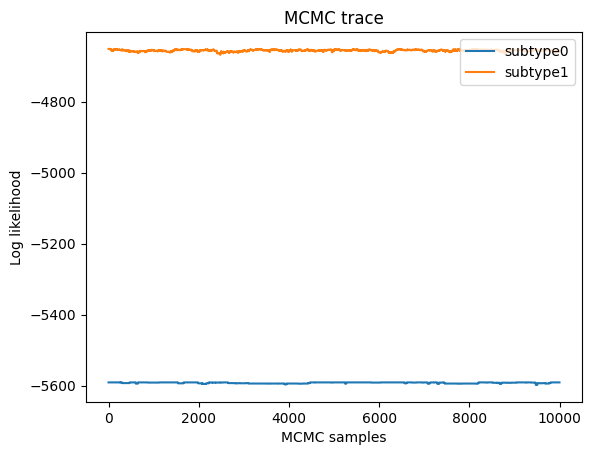

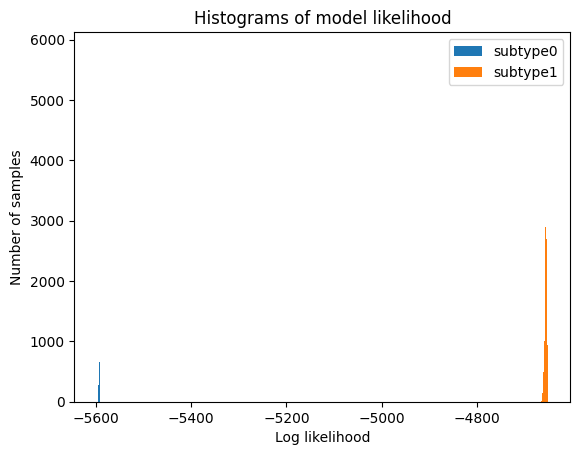

In [15]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pd.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]

    # plot the values as a line plot
    plt.figure(0)
    plt.plot(range(n_iterations_mcmc), samples_likelihood, label="subtype" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')

    # plot the values as a histogramp plot
    plt.figure(1)
    plt.hist(samples_likelihood, label="subtype" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')
    plt.ylabel('Number of samples')
    plt.title('Histograms of model likelihood')


### Evaluate ordering and compare to ground truth

The positional variance diagram shows the estimated event ordering across MCMC samples. Each row is a biomarker event, each column is a SuStaIn stage, and each entry shows the probability that a biomarker has reached a given level at that stage. The colors reflect the level of abnormality: red indicates the first level (z-score 1, ordinal score 1, or event reached), magenta the second level (z-score 2, ordinal score 2), and blue the third level (z-score 3, ordinal score 3). Event biomarkers have only a single transition, so they appear as a single red block. A concentrated block indicates high confidence in the position of that event, while spread across columns indicates uncertainty.

The ground truth sequence is plotted on the left and the estimated sequence is plotted on the right. The ground truth is plotted without uncertainty, while the SuStaIn output reflects variability across MCMC samples. By comparing the two side by side, we can assess how well Mixed-SuStaIn recovered the true progression patterns.

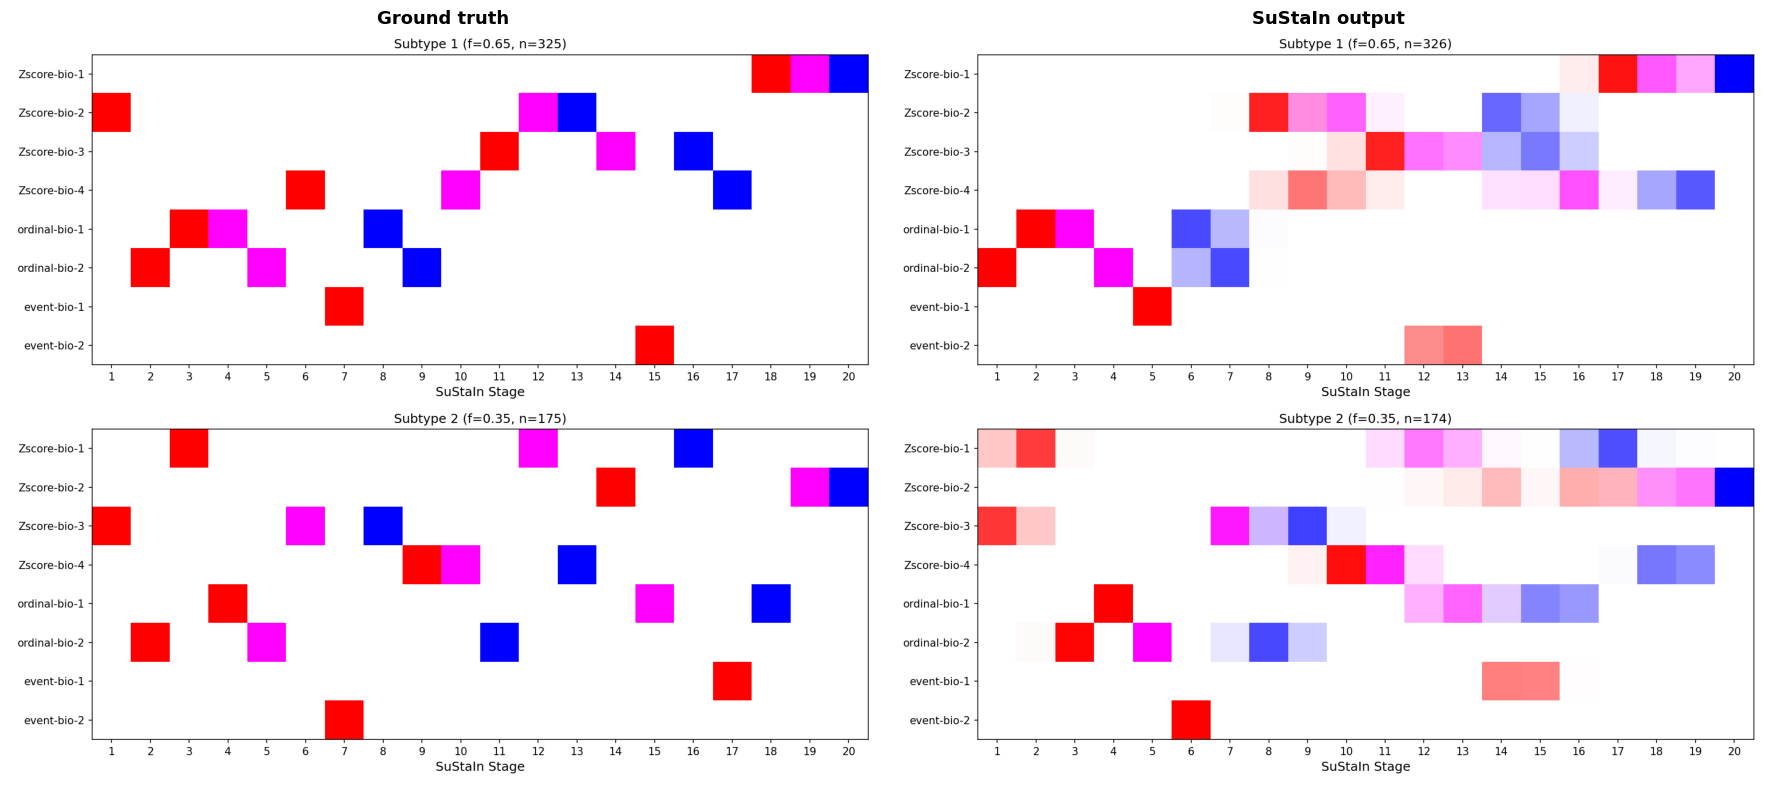

In [16]:
import pickle
import io
from PIL import Image

def fig_to_image(fig):
    """Capture a matplotlib figure as a PIL Image."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    buf.seek(0)
    return Image.open(buf).copy()

# --- Ground truth sequences ---
gt_sequence = np.load('MixedData_gt_sequences.npy')
gt_f = [0.65, 0.35]  # ground truth subtype fractions

# Create dummy MCMC-like arrays for plotting (repeat GT sequence to mimic zero-variance samples)
temp_gt_sequence = np.tile(gt_sequence[:, :, np.newaxis], 100)
temp_gt_f = np.array(gt_f).reshape(-1, 1)

figs_gt, _ = sustain_input._plot_sustain_model(
    temp_gt_sequence, temp_gt_f, data.shape[0],
    subtype_order=tuple(range(N_S_max)), biomarker_labels=biomarker_labels,
)
img_gt = fig_to_image(figs_gt[0])
for f in figs_gt: plt.close(f)

# --- SuStaIn estimated sequences ---
pickle_path = f"{output_folder}/pickle_files/{dataset_name}_subtype{N_S_max - 1}.pickle"
with open(pickle_path, 'rb') as f:
    pk = pickle.load(f)

figs_out, _ = sustain_input._plot_sustain_model(
    pk["samples_sequence"], pk["samples_f"], data.shape[0], biomarker_labels=biomarker_labels,
)
img_out = fig_to_image(figs_out[0])
for f in figs_out: plt.close(f)

# --- Combine side by side ---
h = max(img_gt.height, img_out.height)
img_gt  = img_gt.resize((int(img_gt.width * h / img_gt.height), h), Image.LANCZOS)
img_out = img_out.resize((int(img_out.width * h / img_out.height), h), Image.LANCZOS)

combined = Image.new('RGB', (img_gt.width + img_out.width + 40, h), color='white')
combined.paste(img_gt, (0, 0))
combined.paste(img_out, (img_gt.width + 40, 0))

fig, ax = plt.subplots(figsize=(22, 8))
ax.imshow(combined)
ax.axis('off')
ax.text(img_gt.width / 2,                      -15, 'Ground truth',   ha='center', fontsize=13, fontweight='bold')
ax.text(img_gt.width + 40 + img_out.width / 2, -15, 'SuStaIn output', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Closing remarks

This tutorial demonstrated how to preprocess mixed biomarker types, fit Mixed-SuStaIn, and compare the estimated progression patterns with the ground truth. The maximum likelihood subtype and stage assignments can be used for further downstream analysis.
